### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Load the Data

In [ ]:
df = pd.read_csv("gz2_hart16.csv")

drop_cols = [c for c in df.columns if
             ('_count' in c) or
             ('_weight' in c) or
             ('_flag' in c) or
             ('_fraction' in c and 'debiased' not in c)]

drop_cols += ['dr7objid','ra','dec','rastring','decstring','sample','gz2_class']

df_clean = df.drop(columns=drop_cols)

smooth = df_clean["t01_smooth_or_features_a01_smooth_debiased"]
disk   = df_clean["t01_smooth_or_features_a02_features_or_disk_debiased"]
spiral = df_clean["t04_spiral_a08_spiral_debiased"]

conditions = [
    (smooth > 0.6),                         # Non-spiral
    (disk > 0.5) & (spiral > 0.5)           # Spiral
]

choices = [1, 2]

df_clean["target"] = np.select(conditions, choices, default=0)

In [ ]:
categorical_features = [
    col for col in df.select_dtypes(include=["int64"]).columns
    if col != "TARGET"
]

if categorical_features:
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')

    # Fit and transform categorical features
    encoded_array = encoder.fit_transform(df[categorical_features])

    # Get feature names
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)

    # Create DataFrame for encoded features
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    # Drop original categorical columns and add encoded ones
    df_encoded = df.drop(columns=categorical_features)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
else:
    df_encoded = df.copy()
    encoded_feature_names = []

print(f"\nOriginal shape: {df.shape}")
print(f"After One Hot Encoding shape: {df_encoded.shape}")

X = df_encoded.drop(columns=["TARGET"])
y = df_encoded["TARGET"]


# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["TARGET"] = y.values
df_final


Original shape: (239389, 40)
After One Hot Encoding shape: (239389, 577)


,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t01_smooth_or_features_a03_star_or_artifact_debiased,t02_edgeon_a04_yes_debiased,t02_edgeon_a05_no_debiased,t03_bar_a06_bar_debiased,t03_bar_a07_no_bar_debiased,t04_spiral_a08_spiral_debiased,t04_spiral_a09_no_spiral_debiased,t05_bulge_prominence_a10_no_bulge_debiased,...,total_votes_521,total_votes_527,total_votes_528,total_votes_534,total_votes_536,total_votes_537,total_votes_539,total_votes_584,total_votes_604,target
0,0.000,0.988,0.014252,0.047681,0.953848,0.025,0.975305,1.000000,0.000000,0.050,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,0.024,0.976,0.000000,0.000000,1.000000,0.080,0.920038,1.000000,0.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.780,0.139,0.096200,0.000000,1.000000,0.400,0.600190,0.000000,1.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.036,0.964,0.000000,0.036974,0.963112,0.038,0.962028,0.962366,0.038012,0.077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,0.767,0.186,0.055819,0.125182,0.878825,0.000,1.000000,0.000000,1.000000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239384,0.823,0.174,0.003563,0.857000,0.143000,0.000,1.000000,0.000000,1.000000,1.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
239385,0.541,0.263,0.233967,0.000000,1.000000,0.000,1.000000,0.000000,1.000000,0.750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
239386,0.789,0.156,0.065321,0.000000,1.000000,0.143,0.857000,0.286000,0.714000,0.857,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
239387,0.531,0.278,0.226841,0.000000,1.000000,0.000,1.000000,0.076000,0.924000,0.612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

# LDA (Dimensionality Reduction)

print("LDA")
lda = LinearDiscriminantAnalysis(
    n_components=2        # 3 classes → max 2
)

X_lda = lda.fit_transform(X_resampled, y_resampled)

print("\nDiscriminant Power:")
for i, ratio in enumerate(lda.explained_variance_ratio_):
    print(f" LD{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")


# Final Data

X_final = pd.DataFrame(X_lda, columns=['LD1','LD2'])
y_final = pd.Series(y_resampled)

print("\nFinal shape for FNN:", X_final.shape)

Data sebelum SMOTETomek
Shape X: (239389, 576)
Shape y: (239389,)

Distribusi kelas sebelum SMOTETomek:
target
0    55603
1    86169
2    97617
Name: count, dtype: int64
  Kelas 0: 55603 sampel (23.23%)
  Kelas 1: 86169 sampel (36.00%)
  Kelas 2: 97617 sampel (40.78%)

Class Weights
  Kelas 0: 1.4351
  Kelas 1: 0.9260
  Kelas 2: 0.8174

Data setelah SMOTETomek
Shape X_resampled: (285597, 576)
Shape y_resampled: (285597,)

Distribusi kelas setelah SMOTETomek:
  Kelas 0: 95163 sampel (33.32%)
  Kelas 1: 94712 sampel (33.16%)
  Kelas 2: 95722 sampel (33.52%)

------------------------------------------------------------
LINEAR DISCRIMINANT ANALYSIS
------------------------------------------------------------
Jumlah fitur asli     : 576
Jumlah komponen LDA   : 2

Discriminant Power:
 LD1: 0.8312 (83.12%)
 LD2: 0.1688 (16.88%)

Shape akhir untuk FNN: (285597, 2)


### Simulation

Train set      : 199917 samples (70.0%)
Validation set : 28531 samples (10.0%)
Test set       : 57149 samples (20.0%)
Total          : 285597 samples
Input features : 6

Indices - Train: 199917, Val: 28531, Test: 57149

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (bn3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (attention): Sequential(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
  (fc_out): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3,476
T

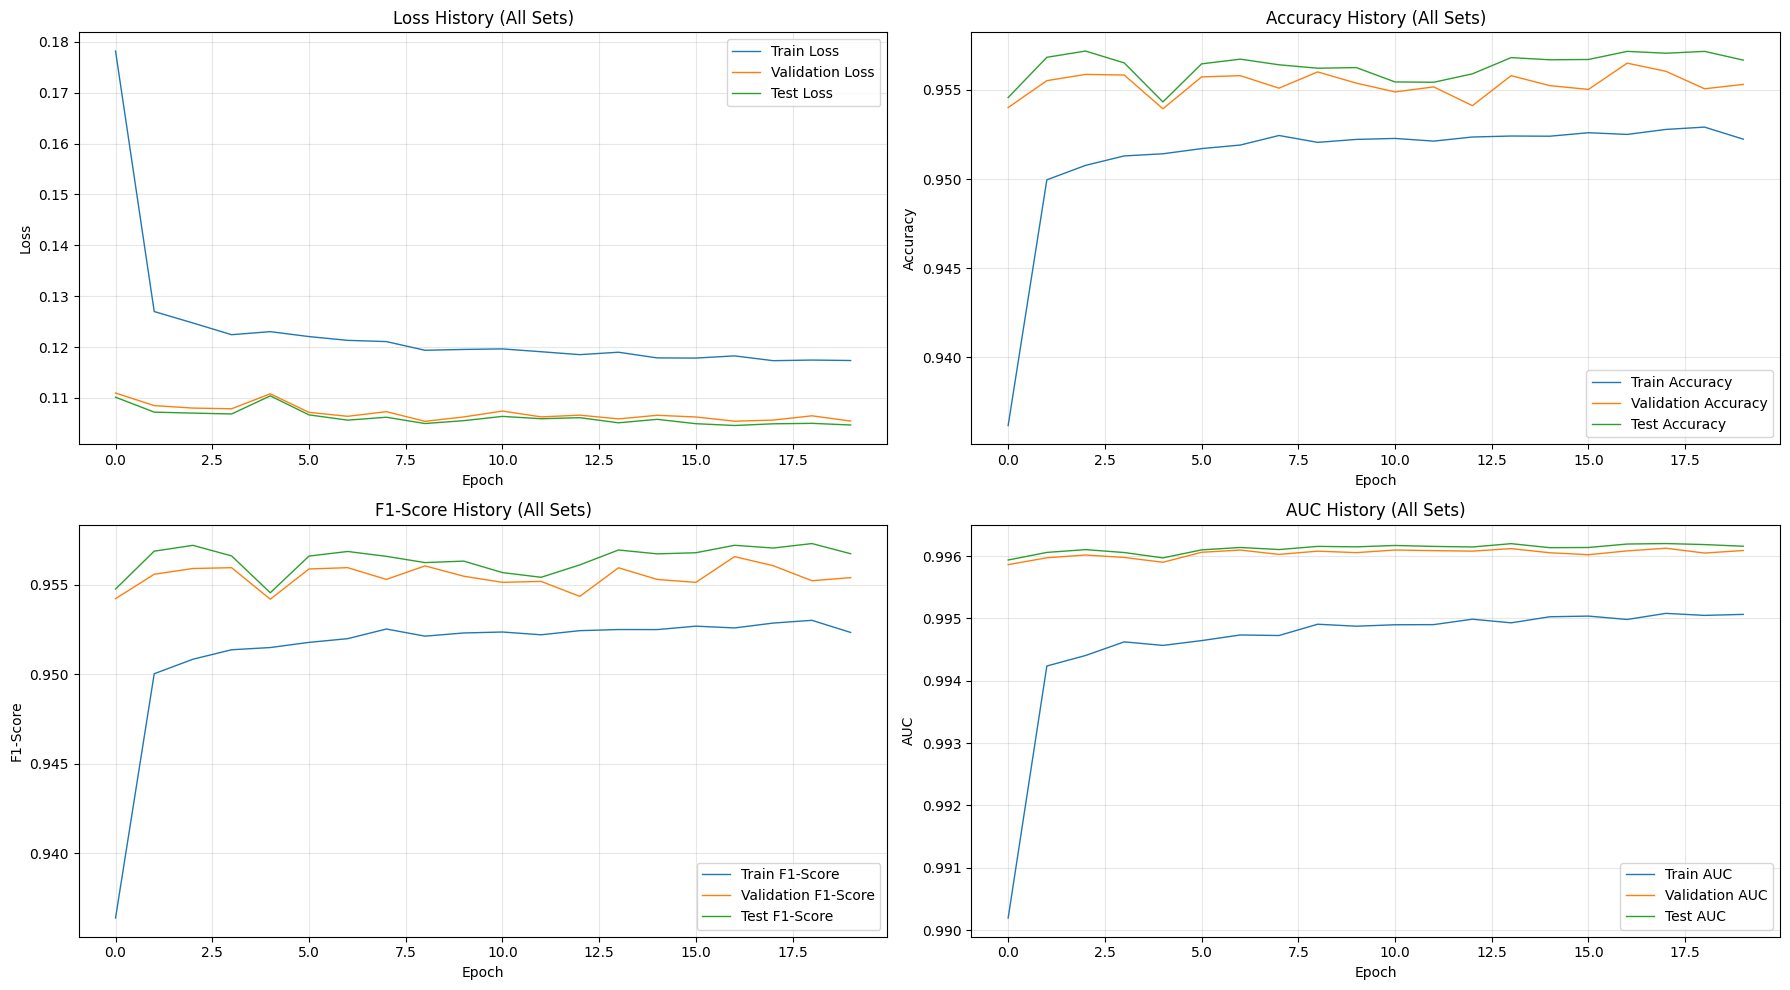


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   Uncertain       0.93      0.94      0.94     19042
  Elliptical       0.98      0.98      0.98     18952
      Spiral       0.96      0.95      0.95     19155

    accuracy                           0.96     57149
   macro avg       0.96      0.96      0.96     57149
weighted avg       0.96      0.96      0.96     57149



<Figure size 800x600 with 0 Axes>

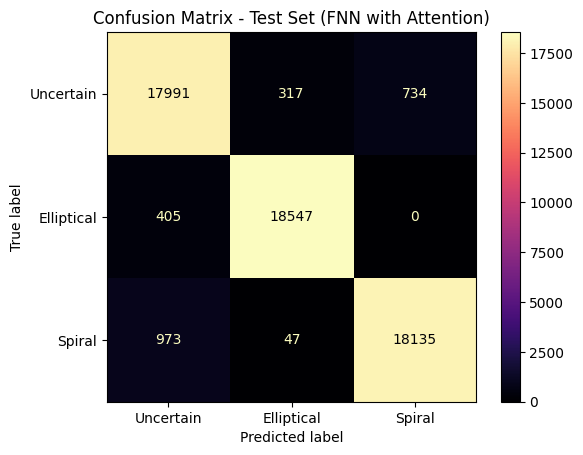


Shape X_test_lda: (57149, 2)
Shape y_test_array: (57149,)
Shape y_pred_array: (57149,)


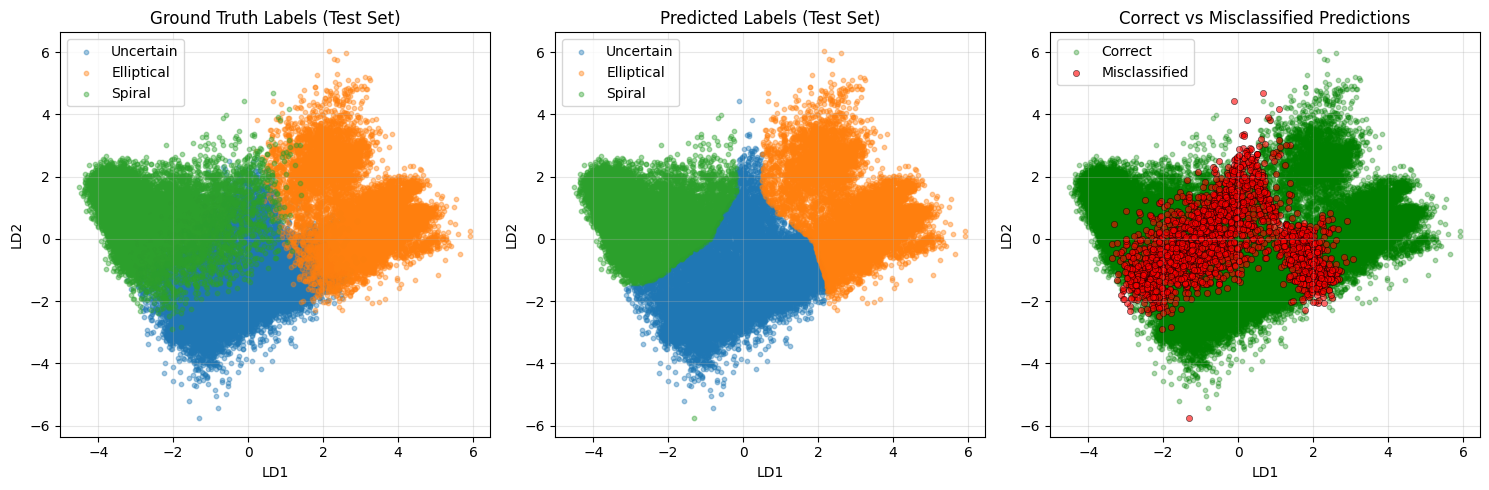

STATISTIK DETAIL
Train Loss         : 0.1174
Validation Loss    : 0.1055
Test Loss          : 0.1047
Train Accuracy     : 0.9522 (95.22%)
Train F1-Score     : 0.9523 (95.23%)
Validation Accuracy: 0.9553 (95.53%)
Validation F1-Score: 0.9554 (95.54%)
Best Validation F1 : 0.9566 (95.66%) at epoch 17
Test Accuracy      : 0.9567 (95.67%)
Test F1-Score      : 0.9567 (95.67%)
Test Precision     : 0.9569 (95.69%)
Test Recall        : 0.9567 (95.67%)
Train set      : 199917 samples (70.0%)
Validation set : 28531 samples (10.0%)
Test set       : 57149 samples (20.0%)
Total          : 285597 samples
Input features : 6

Indices - Train: 199917, Val: 28531, Test: 57149

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


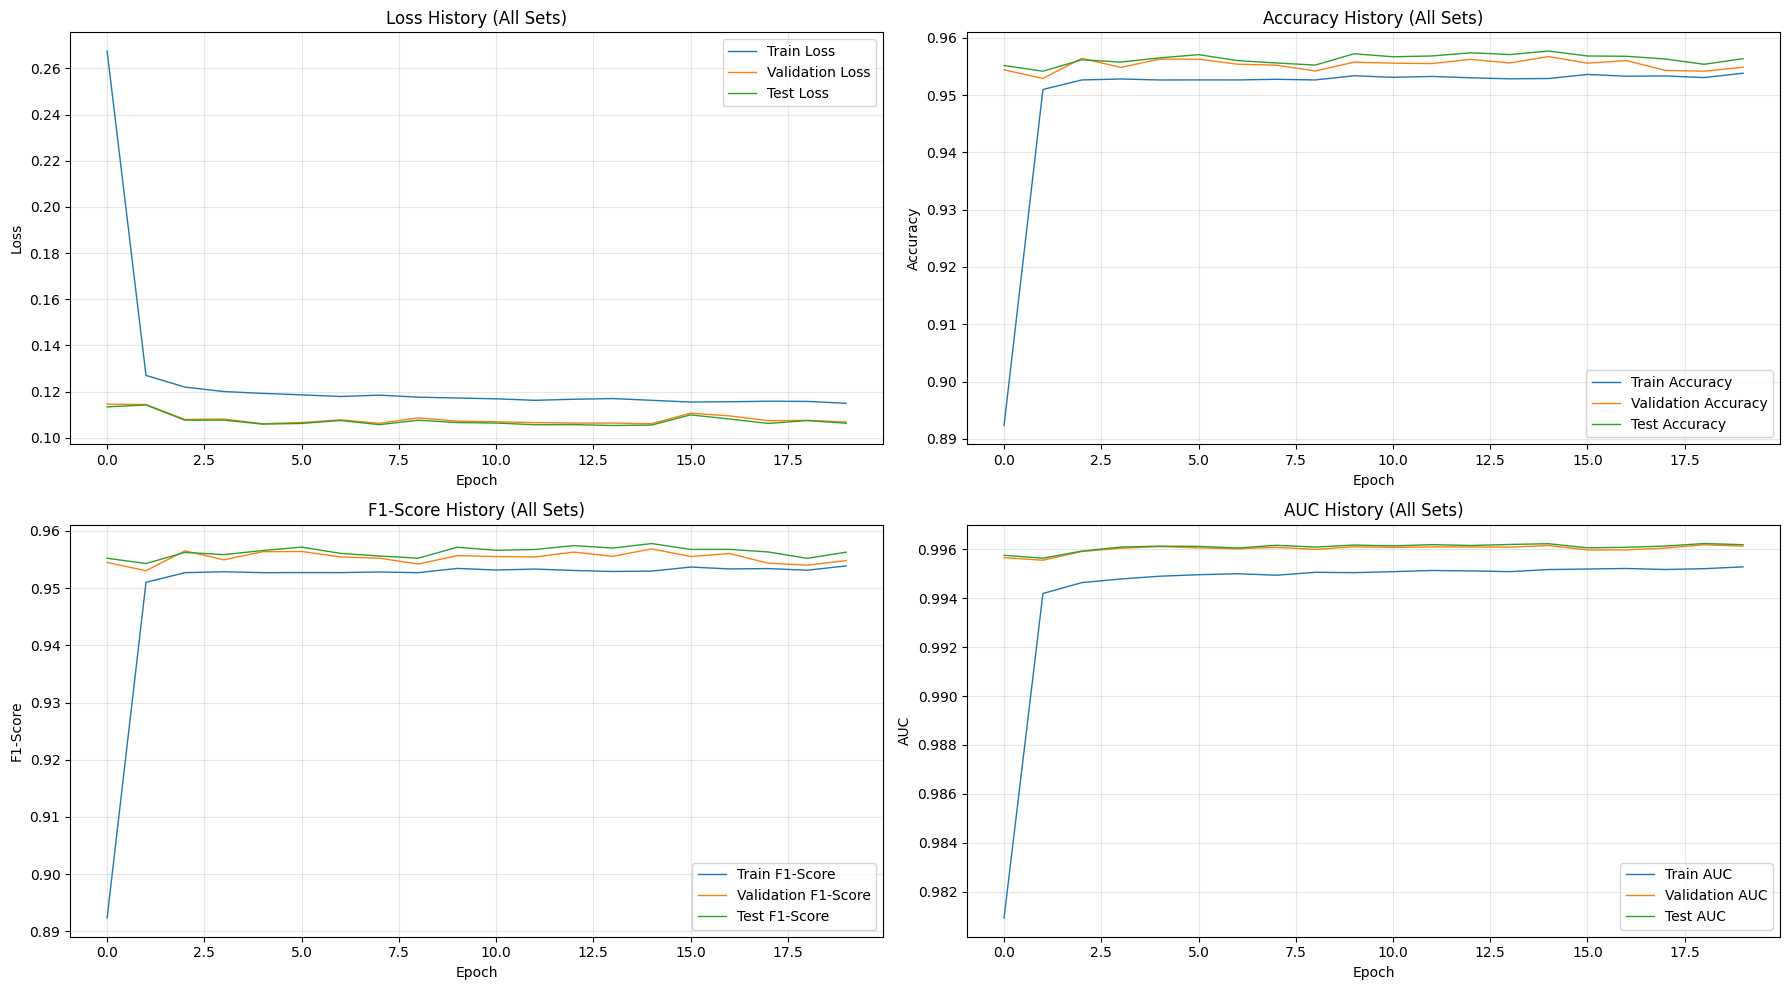


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   Uncertain       0.94      0.93      0.94     19042
  Elliptical       0.97      0.99      0.98     18952
      Spiral       0.96      0.95      0.95     19155

    accuracy                           0.96     57149
   macro avg       0.96      0.96      0.96     57149
weighted avg       0.96      0.96      0.96     57149



<Figure size 800x600 with 0 Axes>

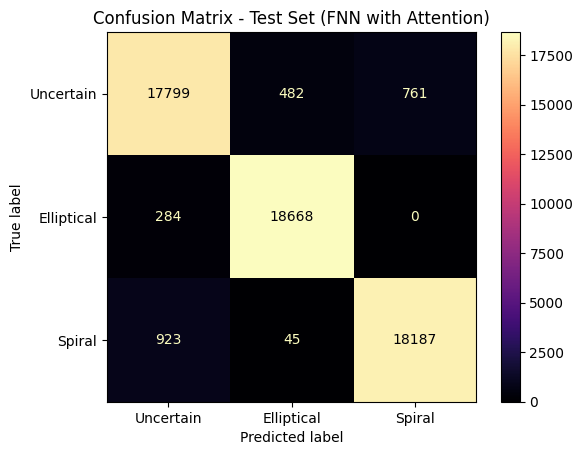


Shape X_test_lda: (57149, 2)
Shape y_test_array: (57149,)
Shape y_pred_array: (57149,)


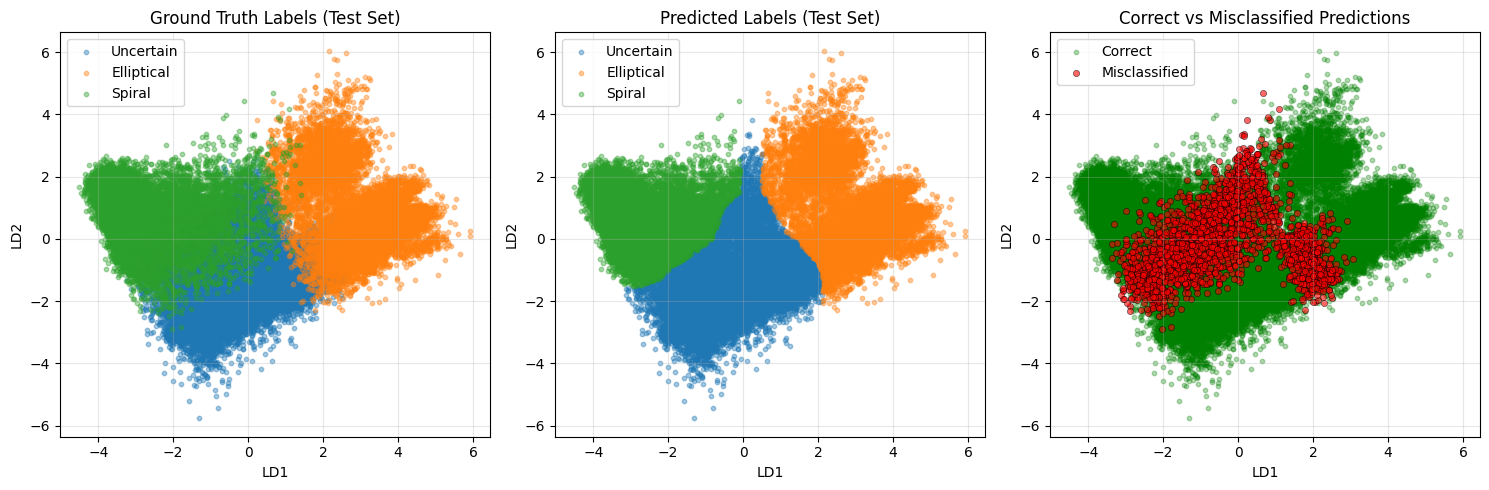

STATISTIK DETAIL
Train Loss         : 0.1149
Validation Loss    : 0.1068
Test Loss          : 0.1063
Train Accuracy     : 0.9538 (95.38%)
Train F1-Score     : 0.9539 (95.39%)
Validation Accuracy: 0.9549 (95.49%)
Validation F1-Score: 0.9548 (95.48%)
Best Validation F1 : 0.9569 (95.69%) at epoch 15
Test Accuracy      : 0.9563 (95.63%)
Test F1-Score      : 0.9563 (95.63%)
Test Precision     : 0.9563 (95.63%)
Test Recall        : 0.9563 (95.63%)
Train set      : 199917 samples (70.0%)
Validation set : 28531 samples (10.0%)
Test set       : 57149 samples (20.0%)
Total          : 285597 samples
Input features : 6

Indices - Train: 199917, Val: 28531, Test: 57149

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


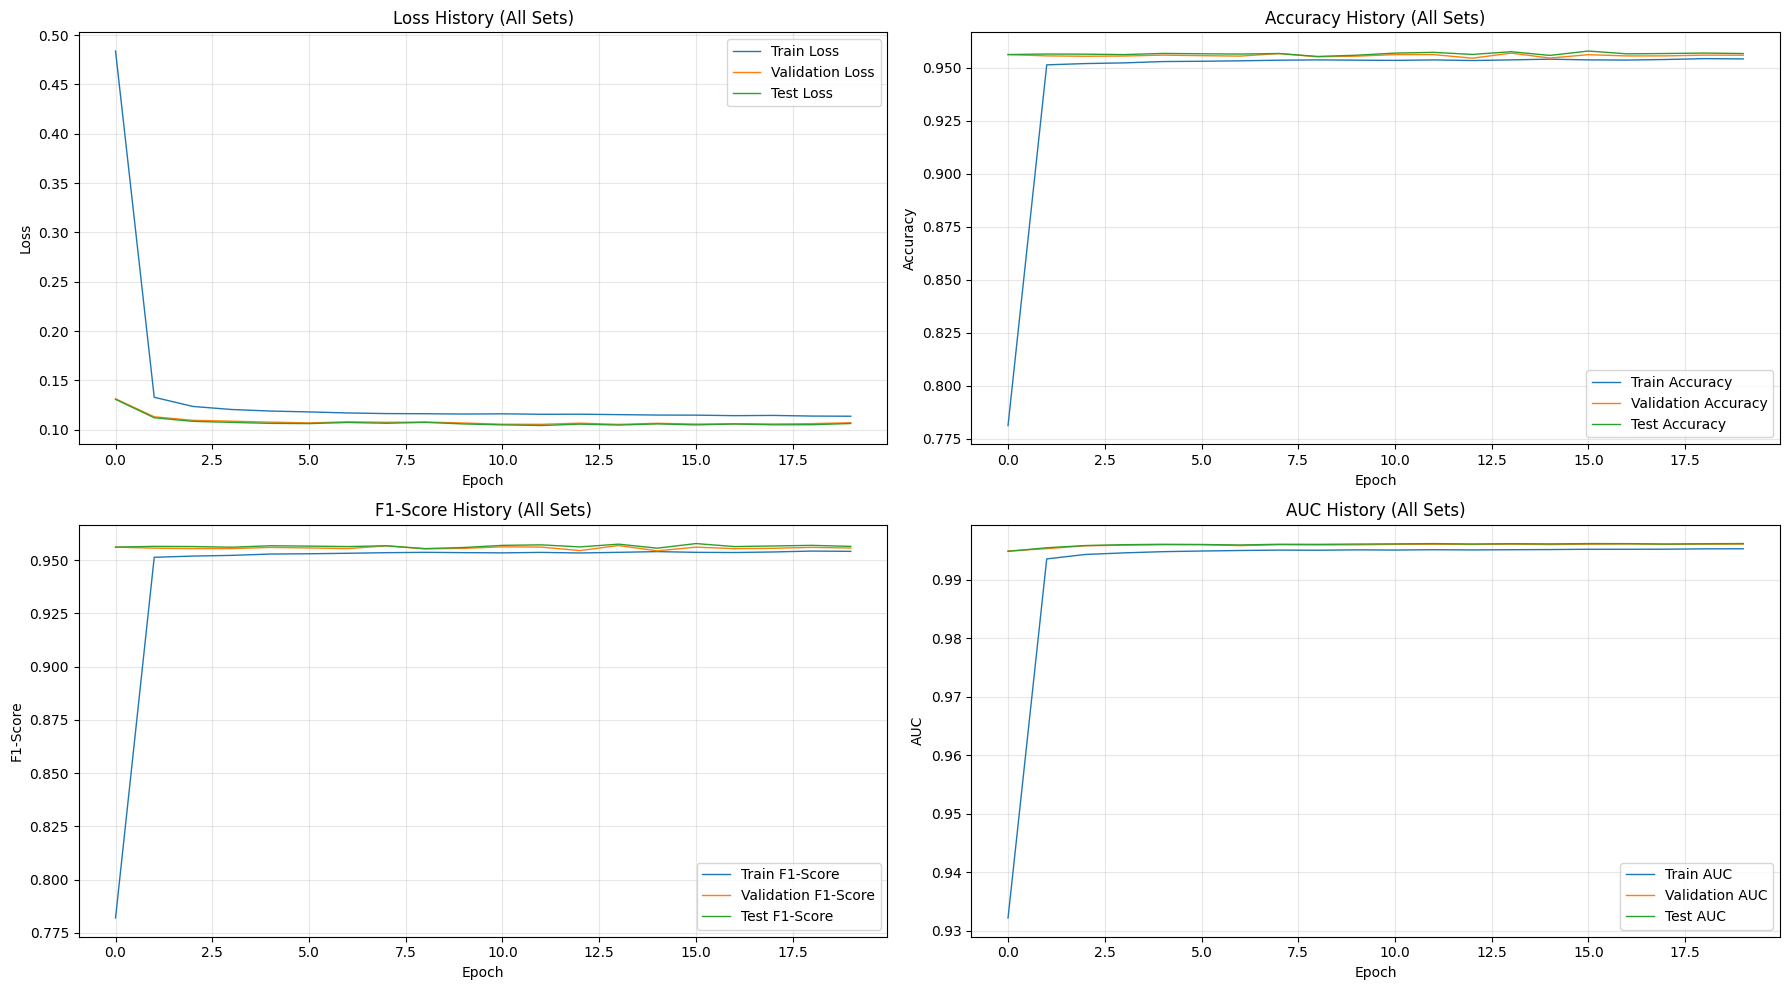


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   Uncertain       0.94      0.93      0.94     19042
  Elliptical       0.97      0.99      0.98     18952
      Spiral       0.95      0.96      0.96     19155

    accuracy                           0.96     57149
   macro avg       0.96      0.96      0.96     57149
weighted avg       0.96      0.96      0.96     57149



<Figure size 800x600 with 0 Axes>

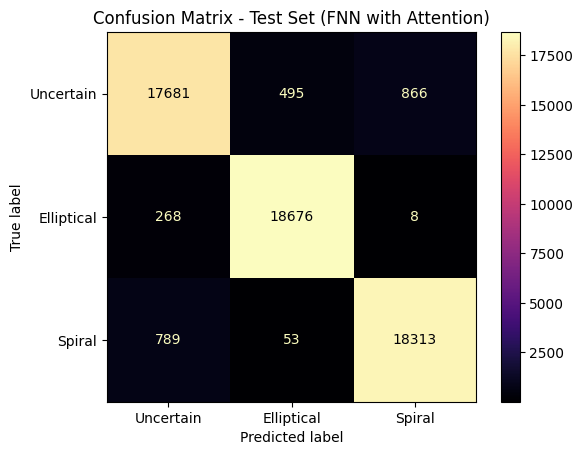


Shape X_test_lda: (57149, 2)
Shape y_test_array: (57149,)
Shape y_pred_array: (57149,)


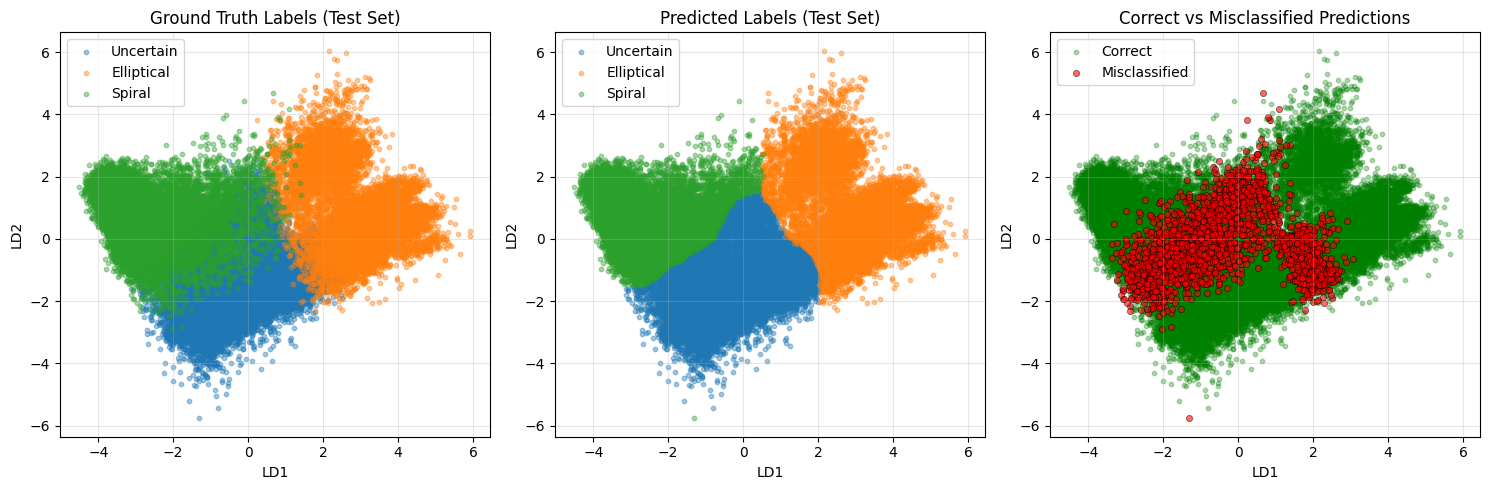

STATISTIK DETAIL
Train Loss         : 0.1138
Validation Loss    : 0.1072
Test Loss          : 0.1064
Train Accuracy     : 0.9541 (95.41%)
Train F1-Score     : 0.9542 (95.42%)
Validation Accuracy: 0.9558 (95.58%)
Validation F1-Score: 0.9557 (95.57%)
Best Validation F1 : 0.9569 (95.69%) at epoch 14
Test Accuracy      : 0.9566 (95.66%)
Test F1-Score      : 0.9565 (95.65%)
Test Precision     : 0.9565 (95.65%)
Test Recall        : 0.9566 (95.66%)
Train set      : 199917 samples (70.0%)
Validation set : 28531 samples (10.0%)
Test set       : 57149 samples (20.0%)
Total          : 285597 samples
Input features : 6

Indices - Train: 199917, Val: 28531, Test: 57149

MODEL ARCHITECTURE
FNNWithAttention(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


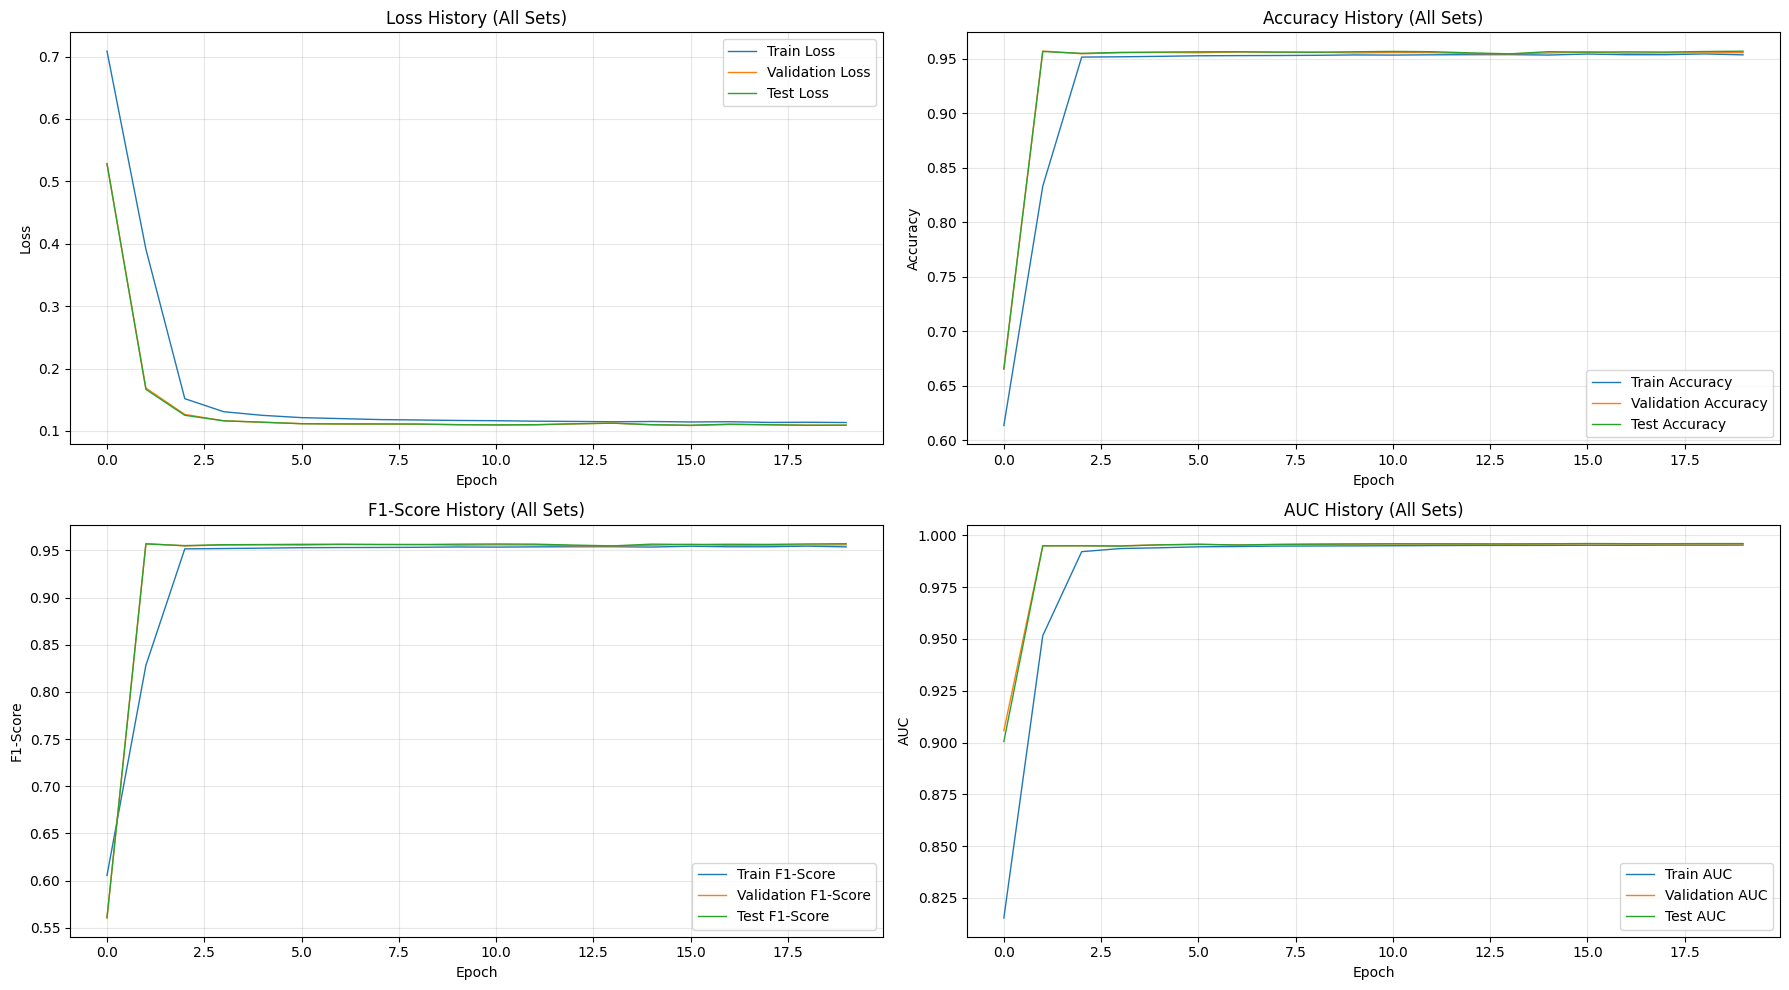


CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   Uncertain       0.92      0.95      0.94     19042
  Elliptical       0.99      0.97      0.98     18952
      Spiral       0.96      0.94      0.95     19155

    accuracy                           0.96     57149
   macro avg       0.96      0.96      0.96     57149
weighted avg       0.96      0.96      0.96     57149



<Figure size 800x600 with 0 Axes>

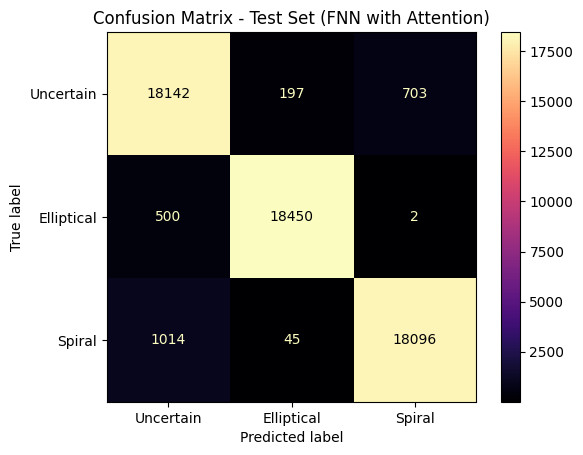


Shape X_test_lda: (57149, 2)
Shape y_test_array: (57149,)
Shape y_pred_array: (57149,)


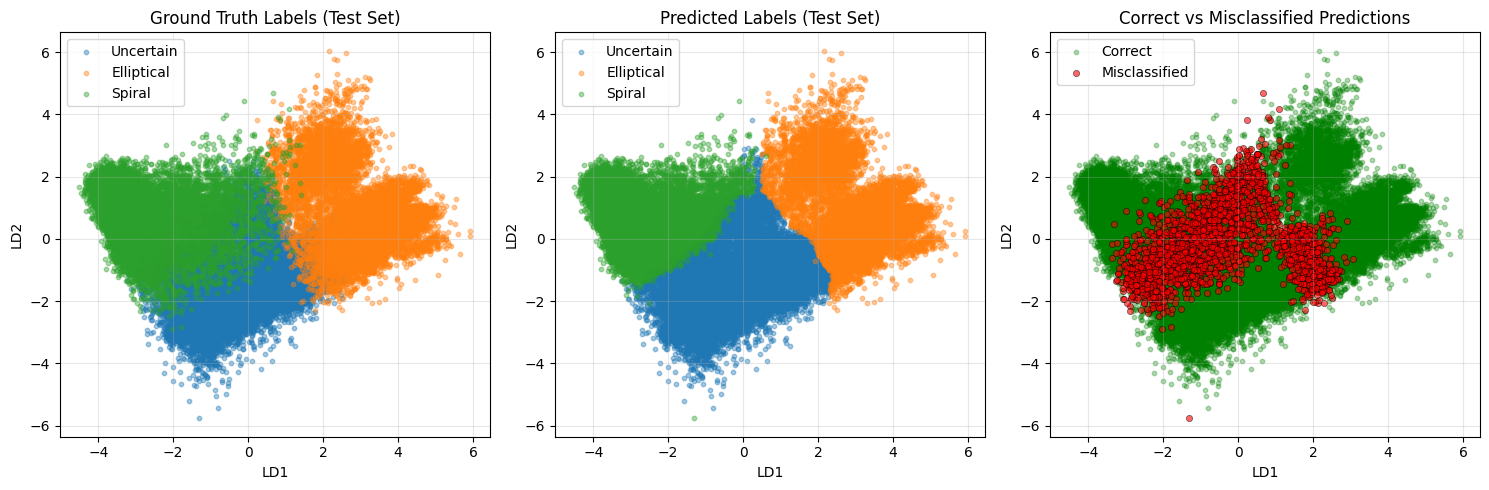

STATISTIK DETAIL
Train Loss         : 0.1135
Validation Loss    : 0.1092
Test Loss          : 0.1092
Train Accuracy     : 0.9536 (95.36%)
Train F1-Score     : 0.9537 (95.37%)
Validation Accuracy: 0.9557 (95.57%)
Validation F1-Score: 0.9559 (95.59%)
Best Validation F1 : 0.9573 (95.73%) at epoch 2
Test Accuracy      : 0.9569 (95.69%)
Test F1-Score      : 0.9571 (95.71%)
Test Precision     : 0.9575 (95.75%)
Test Recall        : 0.9569 (95.69%)


In [ ]:
# Preparation data
# Choose one of parameter arrays to use
batch_size = 32
# batch_size_list = [32, 64, 128, 256]
learning_rate = 0.005
# learning_rate_list = [0.005, 0.01, 0.05, 0.1]
alpha_list = [1, 1.5, 0.5, 0.1]
# alpha = 1
test_acc_results = []
test_auc_results = []
for alpha in alpha_list:
    class LDAFuzzyMembershipMuSigma:
        def __init__(self, X):
            self.X = X
            self.n_features = X.shape[1]
            self.params = []
            self._build_membership()

        def _build_membership(self):
            for i in range(self.n_features):
                xi = self.X[:, i]

                xmin = np.min(xi)
                xmax = np.max(xi)
                mu = np.mean(xi)
                sigma = np.std(xi)

                feature_params = {
                    "low":    [xmin, xmin, mu - alpha*sigma, mu],
                    "medium": [mu - alpha*sigma, mu, mu, mu + alpha*sigma],
                    "high":   [mu, mu + alpha*sigma, xmax, xmax]
                }

                self.params.append(feature_params)

        def trapezoidal(self, x, a, b, c, d):
            return np.maximum(
                np.minimum(
                    np.minimum((x - a) / (b - a + 1e-8), 1),
                    np.minimum((d - x) / (d - c + 1e-8), 1)
                ),
                0
            )

        def compute_membership(self, X_input):
            memberships = []

            for i in range(self.n_features):
                xi = X_input[:, i]
                p = self.params[i]

                low = self.trapezoidal(xi, *p["low"])
                med = self.trapezoidal(xi, *p["medium"])
                high = self.trapezoidal(xi, *p["high"])

                memberships.append(np.stack([low, med, high], axis=1))

            return np.concatenate(memberships, axis=1)

    fuzzy = LDAFuzzyMembershipMuSigma(X_lda)
    X_fuzzy = fuzzy.compute_membership(X_lda)

# Split data 7-1-2
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_fuzzy, y_final, test_size=0.3, random_state=209, stratify=y_final
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.667, random_state=209, stratify=y_temp
    )

    print(f"Train set      : {X_train.shape[0]} samples ({X_train.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Validation set : {X_val.shape[0]} samples ({X_val.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X_fuzzy)*100:.1f}%)")
    print(f"Total          : {len(X_fuzzy)} samples")
    print(f"Input features : {X_fuzzy.shape[1]}")

# Simpan indeks untuk plotting nanti
    train_indices = y_train.index
    val_indices = y_val.index
    test_indices = y_test.index

    print(f"\nIndices - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# Konversi ke tensor
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.values, dtype=torch.long)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define FNN with Attention
    class FNNWithAttention(nn.Module):
        def __init__(self, input_dim, num_classes):
            super(FNNWithAttention, self).__init__()
        
        # Fully connected layers
            self.fc1 = nn.Linear(input_dim, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 32)
            self.bn2 = nn.BatchNorm1d(32)
            self.fc3 = nn.Linear(32, 16)
            self.bn3 = nn.BatchNorm1d(16)
        
        # Attention mechanism
            self.attention = nn.Sequential(
                nn.Linear(16, 8),
                nn.Tanh(),
                nn.Linear(8, 1)
            )
        
        # Output layer
            self.fc_out = nn.Linear(16, num_classes)
        
        # Regularization
            self.dropout = nn.Dropout(0.3)
        
        def forward(self, x):
        # Hidden layers
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.dropout(x)
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.dropout(x)
            x = F.relu(self.bn3(self.fc3(x)))
        
        # Attention weights
            attn_weights = self.attention(x)  # (batch_size, 1)
            attn_weights = F.softmax(attn_weights, dim=0)  # Normalize across batch
        
        # Apply attention (weighted features)
            x_attended = x * attn_weights
        
        # Output
            out = self.fc_out(x_attended)
            return out
  
# Initialization
    model = FNNWithAttention(input_dim=X_fuzzy.shape[1], num_classes=3)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=10, T_mult=2, eta_min=1e-5
            )

    print("\n" + "=" * 60)
    print("MODEL ARCHITECTURE")
    print("=" * 60)
    print(model)

# Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

# Training Loop with Validation
    num_epochs = 20
    train_losses = []
    val_losses = []
    test_losses = []  # Untuk menyimpan test loss per epoch
    train_accs = []
    val_accs = []
    train_f1_scores = []
    val_f1_scores = []
    learning_rates = []
    train_aucs = []
    val_aucs = []
    test_aucs = []

# Untuk evaluasi test per epoch
    test_accs_per_epoch = []
    test_aucs_per_epoch = []
    test_f1_scores_per_epoch = []
    test_precision_per_epoch = []
    test_recall_per_epoch = []

    best_val_f1 = 0.0
    best_epoch = 0
    best_model_state = None
    patience_counter = 0
    early_stop_patience = 30

    print("\n" + "=" * 60)
    print("TRAINING PROGRESS")
    print("=" * 60)

    for epoch in range(num_epochs):
    # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_train_preds = []
        all_train_labels = []
        all_train_probs = []
    
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            probs = F.softmax(outputs, dim=1)
            all_train_probs.extend(probs.detach().cpu().numpy())   
    
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, average='weighted')
        train_auc = roc_auc_score(all_train_labels, all_train_probs, multi_class='ovr', average='weighted')
    
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        train_f1_scores.append(train_f1)
        train_aucs.append(train_auc)
    
    # Validation Phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_val_preds = []
        all_val_labels = []
        all_val_probs = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                probs = F.softmax(outputs, dim=1)
                all_val_probs.extend(probs.detach().cpu().numpy())
    
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_f1 = f1_score(all_val_labels, all_val_preds, average='weighted')
        val_auc = roc_auc_score(all_val_labels, all_val_probs, multi_class='ovr', average='weighted')
        
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_f1_scores.append(val_f1)
        val_aucs.append(val_auc)

    # Test phase (per epoch)
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        all_test_preds = []
        all_test_labels = []
        all_test_probs = []
    
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                all_test_preds.extend(predicted.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())
                probs = F.softmax(outputs, dim=1)
                all_test_probs.extend(probs.detach().cpu().numpy())
    
        test_loss = test_loss / len(test_loader)
        test_acc = test_correct / test_total
        test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
        test_precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
        test_recall = recall_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
        test_auc = roc_auc_score(all_test_labels, all_test_probs, multi_class='ovr', average='weighted')
    
        test_losses.append(test_loss)
        test_accs_per_epoch.append(test_acc)
        test_acc_results.append(test_acc)
        test_f1_scores_per_epoch.append(test_f1)
        test_precision_per_epoch.append(test_precision)
        test_recall_per_epoch.append(test_recall)
        test_aucs_per_epoch.append(test_auc)
        test_auc_results.append(test_auc)

    # Record learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
      
    # Learning rate scheduling
        scheduler.step(val_loss)
    
    # Save best model based on F1-score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
    
    # Early stopping
        if patience_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    # Print progress
        if (epoch + 1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}, Train AUC: {train_auc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_auc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}, Test AUC: {test_auc:.4f} | "
            f"LR: {current_lr:.2e}")

    print(f"\nTraining complete! Best validation F1-score: {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")

# Load best model
    model.load_state_dict(best_model_state)

# Plot metrics history
    plt.figure(figsize=(18, 10))

# Plot loss
    plt.subplot(2, 2, 1)
    plt.plot(train_losses, label='Train Loss', linewidth=1)
    plt.plot(val_losses, label='Validation Loss', linewidth=1)
    plt.plot(test_losses, label='Test Loss', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot accuracy
    plt.subplot(2, 2, 2)
    plt.plot(train_accs, label='Train Accuracy', linewidth=1)
    plt.plot(val_accs, label='Validation Accuracy', linewidth=1)
    plt.plot(test_accs_per_epoch, label='Test Accuracy', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot F1-score
    plt.subplot(2, 2, 3)
    plt.plot(train_f1_scores, label='Train F1-Score', linewidth=1)
    plt.plot(val_f1_scores, label='Validation F1-Score', linewidth=1)
    plt.plot(test_f1_scores_per_epoch, label='Test F1-Score', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.title('F1-Score History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 4)
    plt.plot(train_aucs, label='Train AUC', linewidth=1)
    plt.plot(val_aucs, label='Validation AUC', linewidth=1)
    plt.plot(test_aucs_per_epoch, label='Test AUC', linewidth=1)
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.title('AUC History (All Sets)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

# Classification report
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT - TEST SET")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, 
                              target_names=['Intermediate', 'Non-Spiral', 'Spiral']))

# Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=['Intermediate', 'Non-Spiral', 'Spiral'])

    plt.figure(figsize=(8, 6))
    disp.plot(cmap='magma', values_format='d')
    plt.title('Confusion Matrix - Test Set (FNN with Attention)')
    plt.grid(False)
    plt.show()

# Prediction plot
    X_test_lda = X_lda[test_indices]
    y_test_array = y_test.values
    y_pred_array = np.array(all_preds)

    print(f"\nShape X_test_lda: {X_test_lda.shape}")
    print(f"Shape y_test_array: {y_test_array.shape}")
    print(f"Shape y_pred_array: {y_pred_array.shape}")

    plt.figure(figsize=(15, 5))

# Plot 1: Ground Truth
    plt.subplot(1, 3, 1)
    colors = ['red', 'blue', 'green']
    labels_map = ['Intermediate', 'Non-Spiral', 'Spiral']
    for label in range(3):
        mask = y_test_array == label
        plt.scatter(
            X_test_lda[mask, 0],
            X_test_lda[mask, 1],
        #c=colors[label],
            label=labels_map[label],
            alpha=0.4,
            s=10
        )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Ground Truth Labels (Test Set)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 2: Predictions
    plt.subplot(1, 3, 2)
    for label in range(3):
        mask = y_pred_array == label
        plt.scatter(
            X_test_lda[mask, 0],
            X_test_lda[mask, 1],
        #c=colors[label],
            label=labels_map[label],
            alpha=0.4,
            s=10
        )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Predicted Labels (Test Set)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 3: Correct vs Misclassified
    plt.subplot(1, 3, 3)
    misclassified_mask = y_pred_array != y_test_array
    plt.scatter(
        X_test_lda[~misclassified_mask, 0],
        X_test_lda[~misclassified_mask, 1],
        c='green', label='Correct', alpha=0.3, s=10
    )
    plt.scatter(
        X_test_lda[misclassified_mask, 0],
        X_test_lda[misclassified_mask, 1],
        c='red', label='Misclassified', alpha=0.6, s=20, edgecolors='black', linewidth=0.5
    )
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title('Correct vs Misclassified Predictions')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Results
    print("=" * 60)
    print("Results")
    print("=" * 60)
    print(f"Train Loss         : {train_losses[-1]:.4f}")
    print(f"Validation Loss    : {val_losses[-1]:.4f}")
    print(f"Test Loss          : {test_losses[-1]:.4f}")
    print(f"Train Accuracy     : {train_accs[-1]:.4f} ({train_accs[-1]*100:.2f}%)")
    print(f"Train F1-Score     : {train_f1_scores[-1]:.4f} ({train_f1_scores[-1]*100:.2f}%)")
    print(f"Validation Accuracy: {val_accs[-1]:.4f} ({val_accs[-1]*100:.2f}%)")
    print(f"Validation F1-Score: {val_f1_scores[-1]:.4f} ({val_f1_scores[-1]*100:.2f}%)")
    print(f"Best Validation F1 : {best_val_f1:.4f} ({best_val_f1*100:.2f}%) at epoch {best_epoch+1}")
    print(f"Test Accuracy      : {accuracy_score(all_labels, all_preds):.4f} ({accuracy_score(all_labels, all_preds)*100:.2f}%)")
    print(f"Test F1-Score      : {f1_score(all_labels, all_preds, average='weighted'):.4f} ({f1_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
    print(f"Test Precision     : {precision_score(all_labels, all_preds, average='weighted'):.4f} ({precision_score(all_labels, all_preds, average='weighted')*100:.2f}%)")
    print(f"Test Recall        : {recall_score(all_labels, all_preds, average='weighted'):.4f} ({recall_score(all_labels, all_preds, average='weighted')*100:.2f}%)")

### Plot Sensitivity Analysis

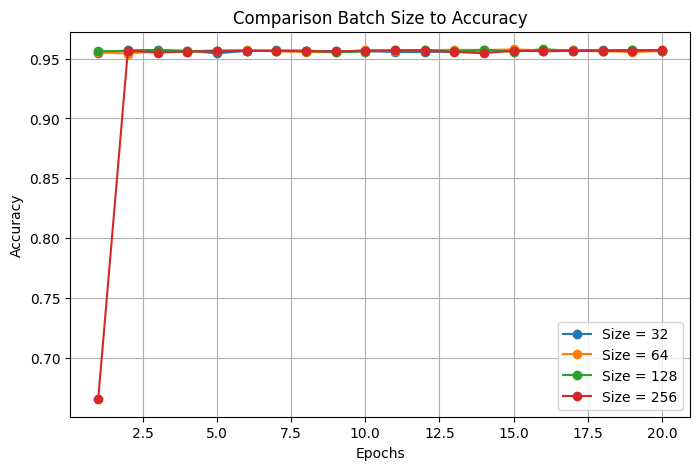

In [ ]:
# Plot Hasil Simulasi
epochs = np.arange(1, num_epochs + 1)
plt.figure(figsize=(8,5))
plt.plot(epochs, test_acc_results[0:int(4*num_epochs*(1/4))], linewidth=1.5, marker='o', label="Size = 32")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(1/4)):int(4*num_epochs*(2/4))], linewidth=1.5, marker='o', label="Size = 64")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(2/4)):int(4*num_epochs*(3/4))], linewidth=1.5, marker='o', label="Size = 128")
plt.plot(epochs, test_acc_results[int(4*num_epochs*(3/4)):], linewidth=1.5, marker='o', label="Size = 256")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Comparison Batch Size to Accuracy")
plt.grid(True)
plt.legend()
plt.show()

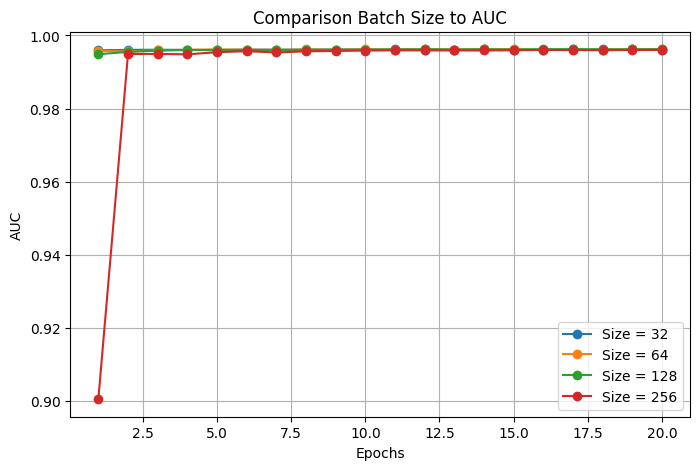

In [15]:
plt.figure(figsize=(8,5))
plt.plot(epochs, test_auc_results[0:int(4*num_epochs*(1/4))], linewidth=1.5, marker='o', label="Size = 32")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(1/4)):int(4*num_epochs*(2/4))], linewidth=1.5, marker='o', label="Size = 64")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(2/4)):int(4*num_epochs*(3/4))], linewidth=1.5, marker='o', label="Size = 128")
plt.plot(epochs, test_auc_results[int(4*num_epochs*(3/4)):], linewidth=1.5, marker='o', label="Size = 256")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.title("Comparison Batch Size to AUC")
plt.grid(True)
plt.legend()
plt.show()